# Day 3 — Machine Learning Model Development

## Objective

Develop and evaluate machine-learning models for predicting industrial equipment failure using the preprocessed sensor data from Day 2.

### Planned Tasks
- Load the preprocessed training and testing datasets.
- Establish a baseline classification model.
- Train a Logistic Regression model.
- Train a Random Forest model.
- Handle class imbalance using class-weighted learning.
- Evaluate models using precision, recall, F1-score, ROC-AUC, and PR-AUC.
- Analyze the confusion matrix.
- Compare model performance.
- Select the model for the next stage of the predictive-maintenance system.

### Project Goal

The model should identify equipment that is at risk of failure so that maintenance can be planned proactively and unexpected downtime can be reduced.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [2]:
processed_path = Path("../data/processed")

X_train = pd.read_csv(processed_path / "X_train.csv")
X_test = pd.read_csv(processed_path / "X_test.csv")

y_train = pd.read_csv(processed_path / "y_train.csv").squeeze()
y_test = pd.read_csv(processed_path / "y_test.csv").squeeze()

In [3]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train: (8000, 7)
X_test: (2000, 7)
y_train: (8000,)
y_test: (2000,)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


## 2. Baseline Model

Before training machine-learning models, a simple baseline is established using a Dummy Classifier.

The baseline always predicts the majority class in the training data. Since machine failures are relatively rare, this provides a useful reference for evaluating whether the machine-learning models actually learn meaningful failure patterns.

Accuracy alone is not sufficient for this problem because the dataset is highly imbalanced. Therefore, recall, precision, F1-score, ROC-AUC, and PR-AUC will also be considered.

In [4]:
from sklearn.dummy import DummyClassifier

In [5]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.97,0.03]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](7,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', ...,'Tool wear [min]','Type_L','Type_M']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,7
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [6]:
y_pred_baseline = baseline_model.predict(X_test)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Precision:", precision_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline Recall:", recall_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline F1:", f1_score(y_test, y_pred_baseline, zero_division=0))

Baseline Accuracy: 0.966
Baseline Precision: 0.0
Baseline Recall: 0.0
Baseline F1: 0.0


## 3. Logistic Regression

Logistic Regression is used as the first machine-learning model because it provides an interpretable baseline for binary classification.

The model predicts the probability that an equipment instance belongs to the failure class.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used so that the minority failure class receives greater weight during training.

In [8]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [9]:
logistic_model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [10]:
y_pred_logistic = logistic_model.predict(X_test)

In [11]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("Logistic Regression Precision:",
      precision_score(y_test, y_pred_logistic, zero_division=0))

print("Logistic Regression Recall:",
      recall_score(y_test, y_pred_logistic, zero_division=0))

print("Logistic Regression F1:",
      f1_score(y_test, y_pred_logistic, zero_division=0))

Logistic Regression Accuracy: 0.8245
Logistic Regression Precision: 0.14177215189873418
Logistic Regression Recall: 0.8235294117647058
Logistic Regression F1: 0.24190064794816415


## 4. Logistic Regression — Confusion Matrix

The confusion matrix shows how the model's predictions are distributed across true positives, true negatives, false positives, and false negatives.

For predictive maintenance, false negatives are particularly important because they represent equipment failures that the system failed to identify.

In [13]:

from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print(cm_logistic)

[[1593  339]
 [  12   56]]


In [14]:
tn, fp, fn, tp = cm_logistic.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 1593
False Positives: 339
False Negatives: 12
True Positives  : 56


In [15]:
y_prob_logistic

array([0.9713345 , 0.53804762, 0.68022315, ..., 0.14863069, 0.59512295,
       0.01708508], shape=(2000,))

## 5. Logistic Regression — ROC-AUC and PR-AUC

Probability-based evaluation provides additional information about the model's ability to distinguish between machines that fail and machines that do not fail.

ROC-AUC measures the model's ability to rank positive and negative cases across different classification thresholds.

PR-AUC focuses on the relationship between precision and recall and is particularly informative when the positive class is rare.

In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

pr_auc_logistic = average_precision_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression ROC-AUC:", roc_auc_logistic)
print("Logistic Regression PR-AUC:", pr_auc_logistic)

Logistic Regression ROC-AUC: 0.9069160272804775
Logistic Regression PR-AUC: 0.38168992620168585


## 6. Random Forest

A Random Forest classifier is trained to capture nonlinear relationships and interactions between equipment sensor variables.

As with Logistic Regression, class weighting is used to account for the strong imbalance between failure and non-failure cases.

In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [18]:
random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [19]:
y_pred_rf = random_forest_model.predict(X_test)

In [20]:
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [21]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Random Forest Precision:",
      precision_score(y_test, y_pred_rf, zero_division=0))

print("Random Forest Recall:",
      recall_score(y_test, y_pred_rf, zero_division=0))

print("Random Forest F1:",
      f1_score(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.981
Random Forest Precision: 0.7272727272727273
Random Forest Recall: 0.7058823529411765
Random Forest F1: 0.7164179104477612


In [22]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print("Random Forest ROC-AUC:", roc_auc_rf)
print("Random Forest PR-AUC:", pr_auc_rf)

Random Forest ROC-AUC: 0.9700135488978201
Random Forest PR-AUC: 0.7807831014007147


## 7. Random Forest — Confusion Matrix

The confusion matrix is used to examine the Random Forest's failure and non-failure predictions in detail.

This is particularly important for predictive maintenance because false negatives represent actual equipment failures that were not detected by the model.

In [23]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1914   18]
 [  20   48]]


In [24]:
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print("True Negatives :", tn_rf)
print("False Positives:", fp_rf)
print("False Negatives:", fn_rf)
print("True Positives  :", tp_rf)

True Negatives : 1914
False Positives: 18
False Negatives: 20
True Positives  : 48


## 8. Random Forest — Feature Importance

Feature importance is used to examine the relative contribution of the input features to the Random Forest's predictions.

This analysis helps identify which equipment measurements are most informative for the predictive-maintenance model and can support the development of maintenance insights.

In [25]:
feature_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance

Torque [Nm]                0.327580
Rotational speed [rpm]     0.284351
Tool wear [min]            0.211003
Air temperature [K]        0.097730
Process temperature [K]    0.063719
Type_L                     0.008964
Type_M                     0.006653
dtype: float64

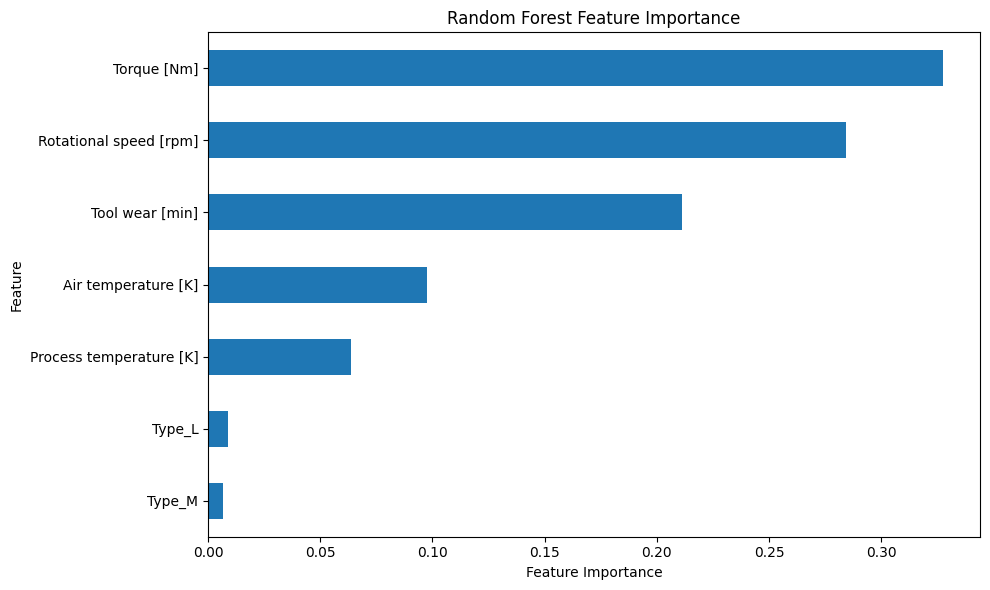

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 9. Model Comparison

The baseline, Logistic Regression, and Random Forest models are compared using the same evaluation metrics.

Because machine failure is a highly imbalanced target, precision, recall, F1-score, ROC-AUC, and PR-AUC are considered alongside accuracy.

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, zero_division=0),
        precision_score(y_test, y_pred_logistic, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, zero_division=0),
        recall_score(y_test, y_pred_logistic, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, y_pred_baseline, zero_division=0),
        f1_score(y_test, y_pred_logistic, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC-AUC": [
        np.nan,
        roc_auc_logistic,
        roc_auc_rf
    ],
    "PR-AUC": [
        np.nan,
        pr_auc_logistic,
        pr_auc_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Dummy Baseline,0.9660,0.000000,0.000000,0.000000,NaN,NaN
1,Logistic Regression,0.8245,0.141772,0.823529,0.241901,0.906916,0.381690
2,Random Forest,0.9810,0.727273,0.705882,0.716418,0.970014,0.780783


## 10. Save Trained Model

The trained Random Forest model is saved so that it can be loaded later by the monitoring system without retraining the model.

In [29]:
import joblib
from pathlib import Path

models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

joblib.dump(
    random_forest_model,
    models_path / "random_forest_model.joblib"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


## Day 3 Complete — Model Development

Two machine-learning approaches were developed for equipment failure prediction: Logistic Regression and Random Forest, along with a majority-class baseline.

The dataset's class imbalance was addressed using class-weighted learning for the machine-learning models.

Logistic Regression achieved high failure recall but produced a large number of false-positive predictions.

Random Forest produced higher precision, F1-score, ROC-AUC, and PR-AUC, while maintaining substantial failure detection capability. Its confusion matrix contained 48 true positives, 18 false positives, 20 false negatives, and 1,914 true negatives.

Random Forest feature importance indicated that torque, rotational speed, and tool wear were the most influential features in the model's predictions.

The trained models and evaluation results provide the foundation for the next stage: implementing equipment health monitoring, failure-risk scoring, and maintenance alerts.